In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [4]:
# 4. Load dataset
df = pd.read_csv('Iris.csv')

In [5]:
# 5. Check rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 6)


In [6]:
# 6. Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [7]:
# 7. Select features
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df[features]

In [8]:
# 8. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# 9. Calculate linkage
linked = linkage(X_scaled, method='ward')

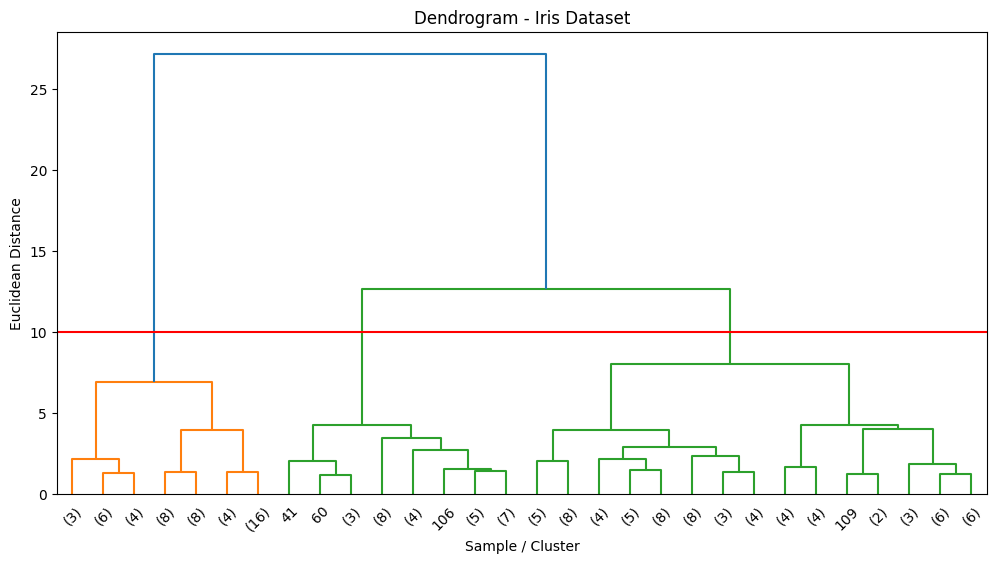

In [10]:
# 10. Generate Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.axhline(y=10, color='r', linestyle='-')
plt.title('Dendrogram - Iris Dataset')
plt.xlabel('Sample / Cluster')
plt.ylabel('Euclidean Distance')
plt.show()

In [12]:
# 11. Create model
model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

In [13]:
# 12. Fit and predict
y_hc = model.fit_predict(X_scaled)

In [14]:
# 13. Create Cluster column
df['Cluster'] = y_hc

In [15]:
# 14. Count samples in each cluster
print(df['Cluster'].value_counts().sort_index())

Cluster
0    71
1    49
2    30
Name: count, dtype: int64


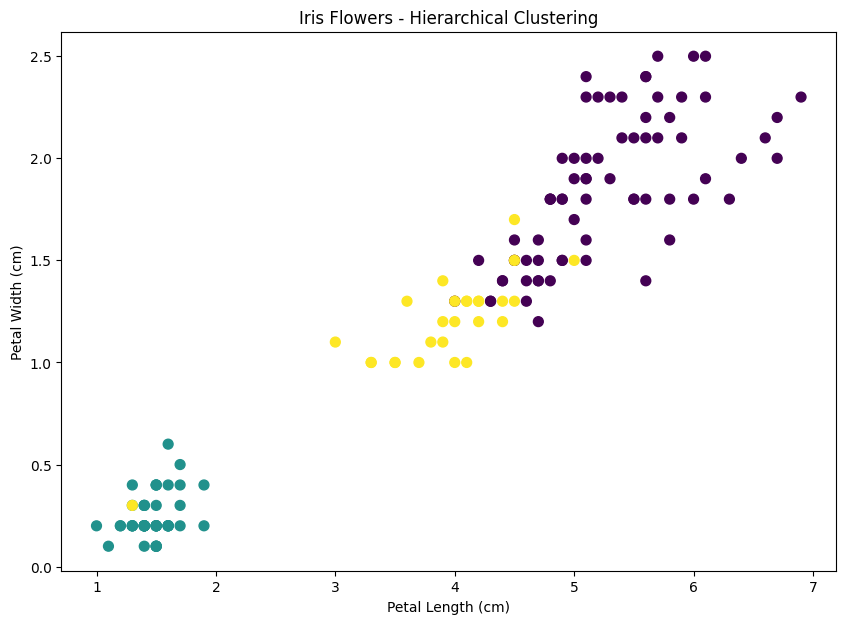

In [16]:
# 15. Create Scatter Plot
plt.figure(figsize=(10, 7))
plt.scatter(df['PetalLengthCm'], df['PetalWidthCm'], c=df['Cluster'], s=50, cmap='viridis')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Flowers - Hierarchical Clustering')
plt.show()

In [17]:
# 16. Compare clusters with the actual species
comparison = pd.crosstab(df['Cluster'], df['Species'])
print(comparison)

Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               23              48
1                 49                0               0
2                  1               27               2
